# Laptop Data Visualization Notebook

This notebook explores cleaned laptop data and supports model-related visual analysis.

## Section Guide
1. Dataset understanding visuals.
2. Regression model performance visuals.
3. Additional feature engineering for model preparation.
4. Export model-ready dataset.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')

df = pd.read_csv('data/processed/cleaned_laptop_data.csv')

# Feature engineering for visualisations
cpu_lower = df['Cpu'].str.lower()

df['Processor_Brand'] = df['Cpu'].str.split().str[0]

def cpu_family(cpu: str) -> str:
    value = str(cpu).lower()
    if 'core i9' in value:
        return 'Intel Core i9'
    if 'core i7' in value:
        return 'Intel Core i7'
    if 'core i5' in value:
        return 'Intel Core i5'
    if 'core i3' in value:
        return 'Intel Core i3'
    if 'ryzen' in value:
        return 'AMD Ryzen'
    if 'celeron' in value:
        return 'Intel Celeron'
    if 'pentium' in value:
        return 'Intel Pentium'
    if 'xeon' in value:
        return 'Intel Xeon'
    if 'a9' in value or 'a6' in value or 'a12' in value or 'a10' in value:
        return 'AMD A-Series'
    return 'Other'

df['Processor_Family'] = df['Cpu'].apply(cpu_family)
df['Is_Gaming_Laptop'] = df['TypeName'].str.contains('Gaming', case=False, na=False)

df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Processor_Brand,Processor_Family,Is_Gaming_Laptop
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,Intel Core i5,False
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,Intel Core i5,False
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,Intel Core i5,False
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,Intel Core i7,False
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,Intel Core i5,False


## 1) Dataset Understanding Visuals

Use standalone Seaborn charts to inspect distribution, spread, and key feature patterns.

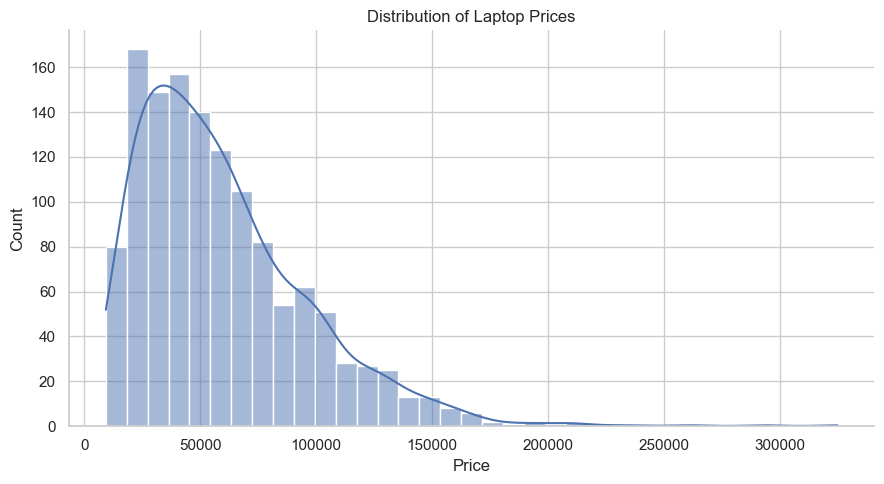

In [37]:
# 1) Price distribution
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='Price', bins=35, kde=True, edgecolor='white')
plt.title('Distribution of Laptop Prices')
plt.xlabel('Price')
plt.ylabel('Count')
sns.despine()
plt.tight_layout()
plt.show()

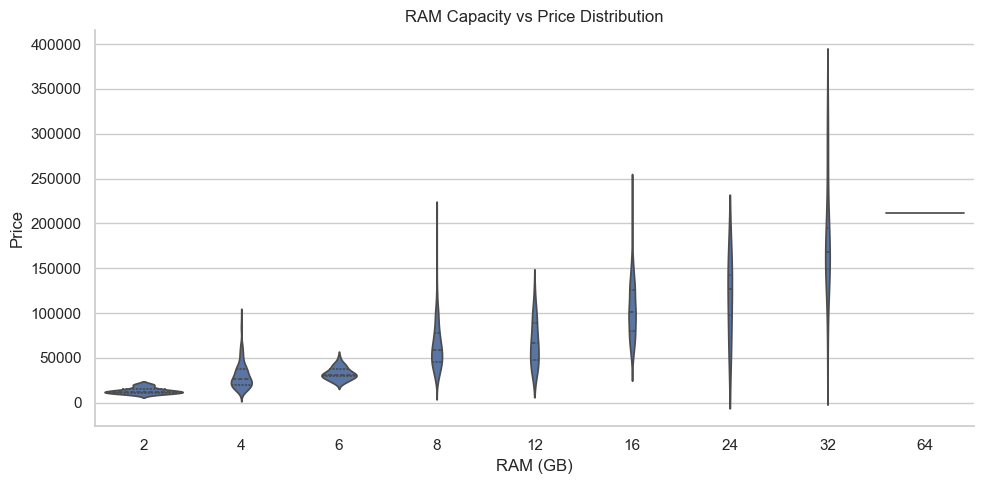

In [38]:
# 5) RAM vs price trend
ram_order = sorted(df['Ram'].astype(str).str.replace('GB', '', regex=False).astype(int).unique())
plot_df = df.copy()
plot_df['Ram_GB'] = plot_df['Ram'].astype(str).str.replace('GB', '', regex=False).astype(int)

plt.figure(figsize=(10, 5))
sns.violinplot(data=plot_df, x='Ram_GB', y='Price', order=ram_order, inner='quartile')
plt.title('RAM Capacity vs Price Distribution')
plt.xlabel('RAM (GB)')
plt.ylabel('Price')
sns.despine()
plt.tight_layout()
plt.show()

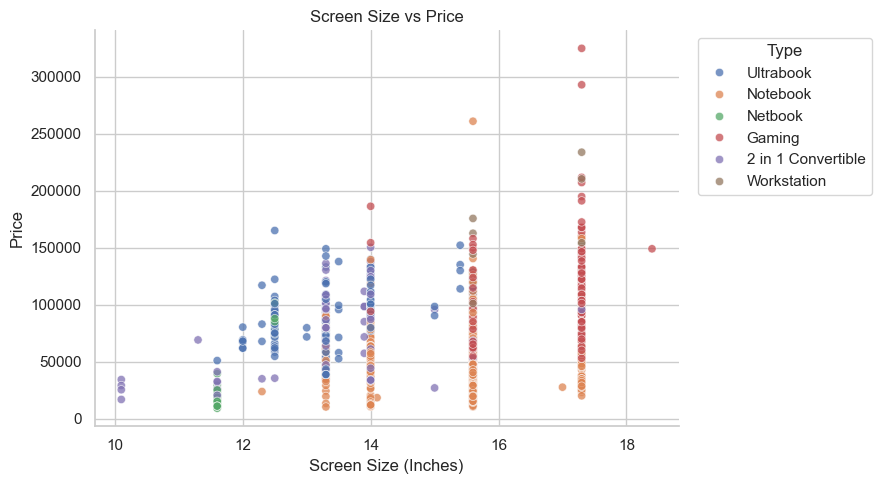

In [39]:
# 4) Screen size vs price pattern
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Inches', y='Price', hue='TypeName', alpha=0.75)
plt.title('Screen Size vs Price')
plt.xlabel('Screen Size (Inches)')
plt.ylabel('Price')
plt.legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

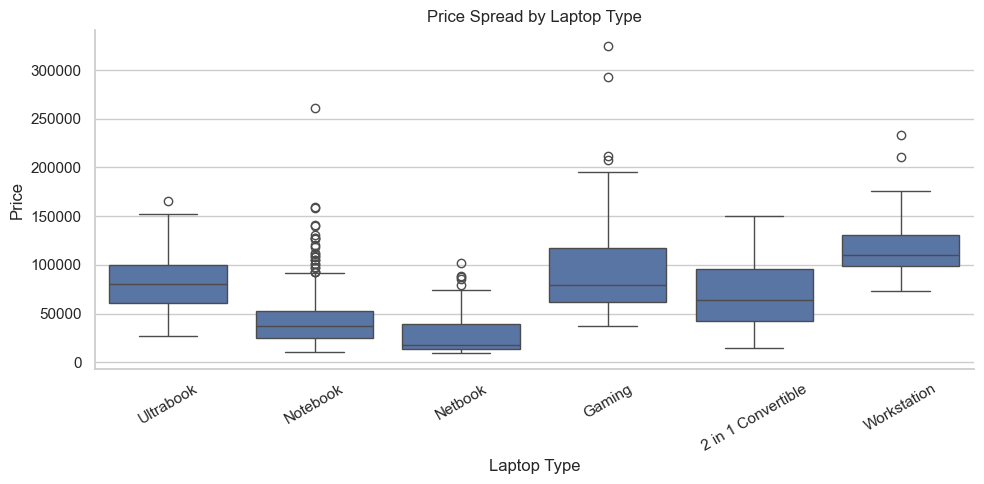

In [40]:
# 3) Price by laptop type
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='TypeName', y='Price')
plt.title('Price Spread by Laptop Type')
plt.xlabel('Laptop Type')
plt.ylabel('Price')
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

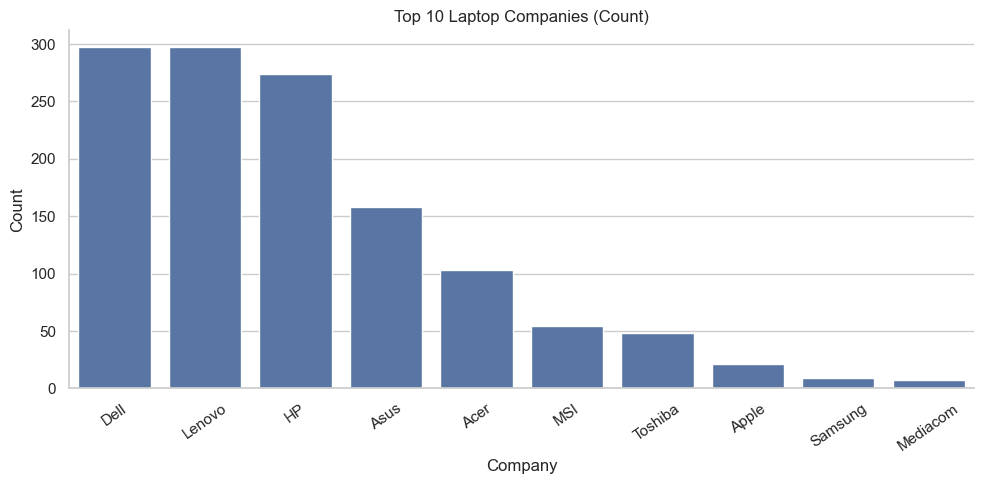

In [41]:
# 2) Top companies by count
top_companies = df['Company'].value_counts().head(10).index
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['Company'].isin(top_companies)], x='Company', order=top_companies)
plt.title('Top 10 Laptop Companies (Count)')
plt.xlabel('Company')
plt.ylabel('Count')
plt.xticks(rotation=35)
sns.despine()
plt.tight_layout()
plt.show()

## 2) Regression Model Performance Visuals

Fit a baseline linear regression pipeline and inspect prediction quality and residual behavior.

In [34]:
# Model setup: prepare features, train/test split (first 70% train, last 30% test), and evaluate
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_df = df.copy()
model_df['Touchscreen'] = model_df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
model_df['Ips'] = model_df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)

resolution_split = model_df['ScreenResolution'].str.split('x', n=1, expand=True)
model_df['X_res'] = resolution_split[0].str.replace(',', '').str.findall(r'(\d+\.?\d+)').apply(lambda x: x[0]).astype(int)
model_df['Y_res'] = resolution_split[1].astype(int)
model_df['ppi'] = np.sqrt((model_df['X_res'] ** 2) + (model_df['Y_res'] ** 2)) / model_df['Inches']

model_df['Ram'] = model_df['Ram'].astype(str).str.replace('GB', '', regex=False).astype(float)
model_df['Weight'] = model_df['Weight'].astype(str).str.replace('kg', '', regex=False).astype(float)

X = model_df.drop(columns=['Price'])
y = model_df['Price']

split_idx = int(len(model_df) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

results_df = pd.DataFrame({
    'Actual Price': y_test.to_numpy(),
    'Predicted Price': y_pred,
    'Residual': y_test.to_numpy() - y_pred
})
results_df['Abs Error'] = results_df['Residual'].abs()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('Linear Regression Performance')
print(f'MAE  : {mae:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'R²   : {r2:.4f}')

Linear Regression Performance
MAE  : 13,220.13
RMSE : 19,989.57
R²   : 0.6836


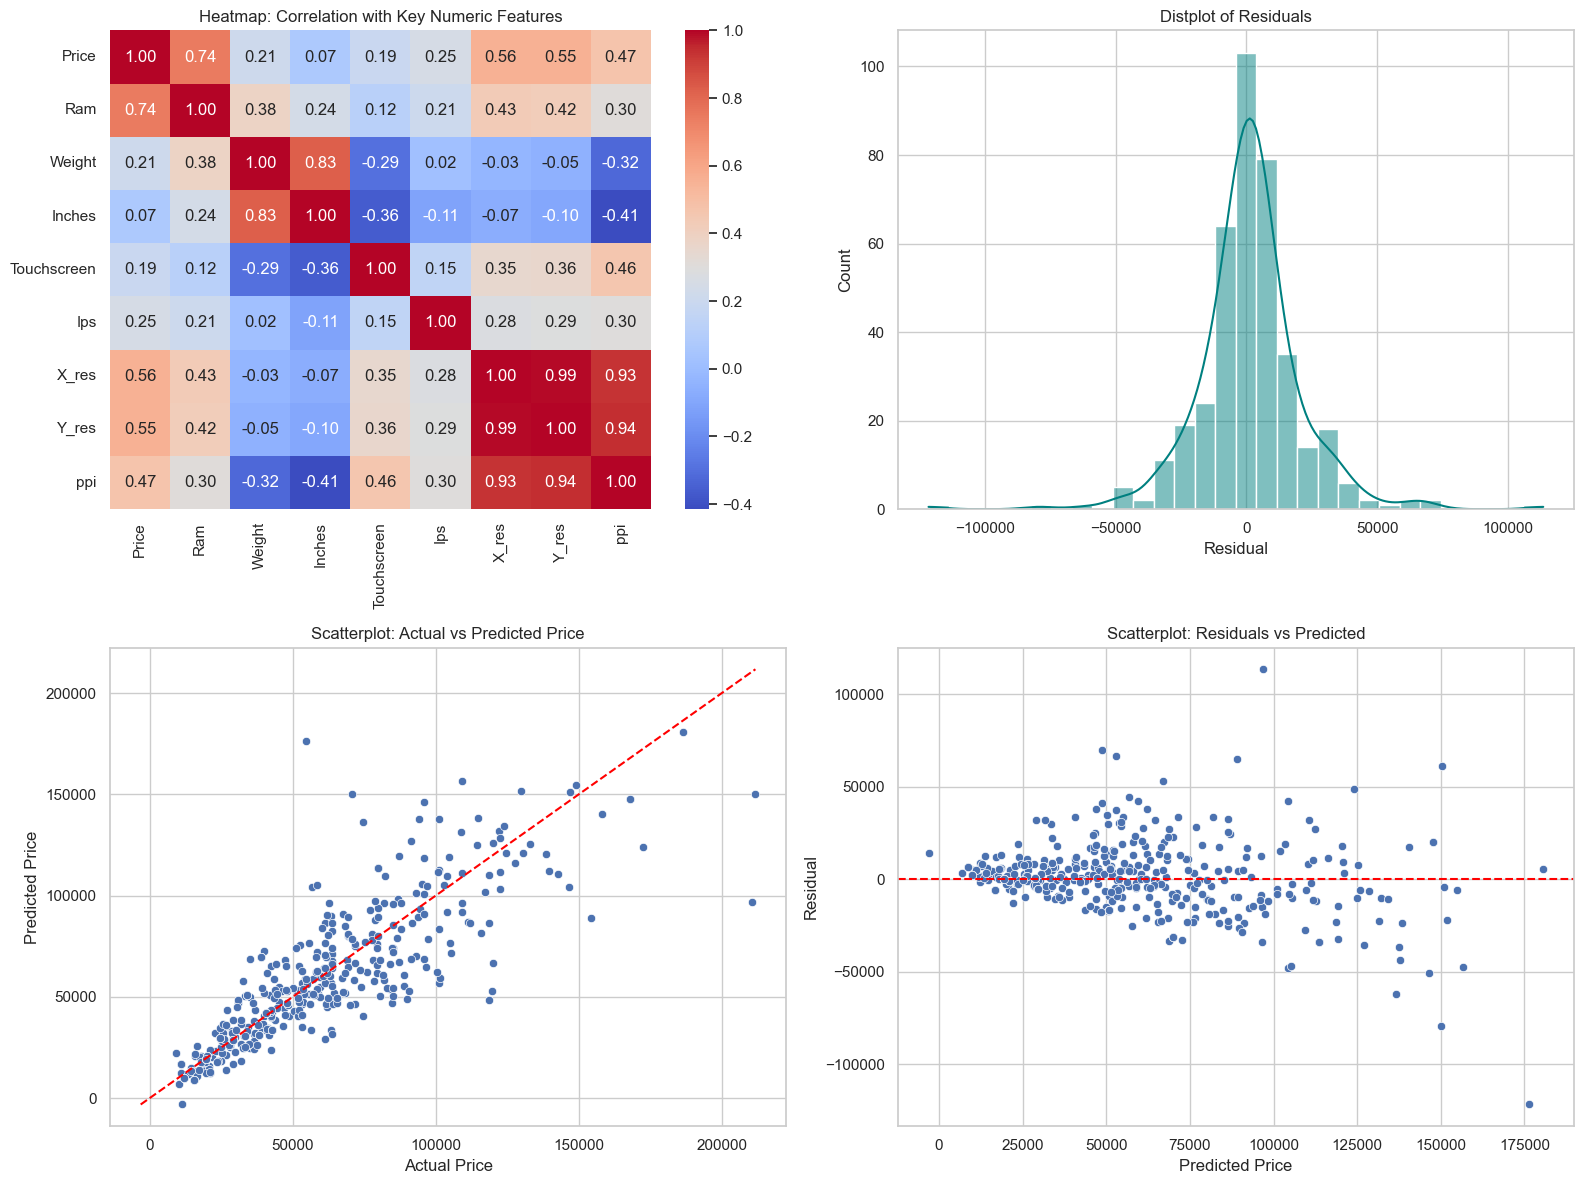

In [35]:
# Core model-result visuals: heatmap, distplot-style residuals, and scatterplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

corr_cols = ['Price', 'Ram', 'Weight', 'Inches', 'Touchscreen', 'Ips', 'X_res', 'Y_res', 'ppi']
corr_matrix = model_df[corr_cols].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0, 0])
axes[0, 0].set_title('Heatmap: Correlation with Key Numeric Features')

sns.histplot(results_df['Residual'], kde=True, bins=30, color='teal', ax=axes[0, 1])
axes[0, 1].set_title('Distplot of Residuals')
axes[0, 1].set_xlabel('Residual')

sns.scatterplot(data=results_df, x='Actual Price', y='Predicted Price', ax=axes[1, 0])
min_val = min(results_df['Actual Price'].min(), results_df['Predicted Price'].min())
max_val = max(results_df['Actual Price'].max(), results_df['Predicted Price'].max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
axes[1, 0].set_title('Scatterplot: Actual vs Predicted Price')

sns.scatterplot(data=results_df, x='Predicted Price', y='Residual', ax=axes[1, 1])
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_title('Scatterplot: Residuals vs Predicted')

plt.tight_layout()
plt.show()

In [22]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)


In [13]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Processor_Brand,Processor_Family,Is_Gaming_Laptop,Touchscreen
819,Dell,Notebook,14.0,1366x768,Intel Core i5 6200U 2.3GHz,4,500GB HDD,Intel HD Graphics 520,Windows 10,1.76,40226.4000,Intel,Intel Core i5,False,0
181,Dell,Ultrabook,13.3,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,1.23,74538.7200,Intel,Intel Core i5,False,0
919,MSI,Gaming,15.6,Full HD 1920x1080,Intel Core i5 7300HQ 2.5GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.20,59668.8048,Intel,Intel Core i5,True,0
880,HP,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,4,256GB SSD,Intel HD Graphics 620,Windows 10,1.28,90576.0000,Intel,Intel Core i5,False,1
121,MSI,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD + 2TB HDD,Nvidia GeForce GTX 1070,Windows 10,1.80,119427.1200,Intel,Intel Core i7,True,0


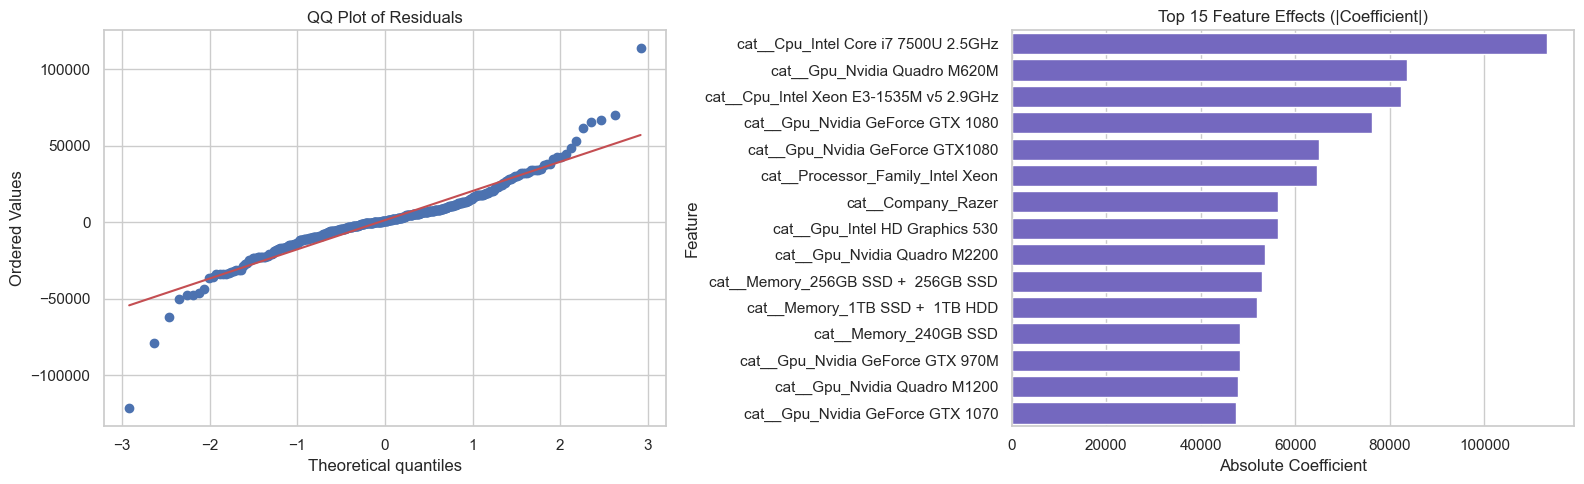

In [36]:
# Additional relevant diagnostics: QQ plot and top coefficient impact
from scipy import stats

feature_names = linear_model.named_steps['preprocessor'].get_feature_names_out()
coef_values = linear_model.named_steps['regressor'].coef_
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef_values})
coef_df['Abs Coefficient'] = coef_df['Coefficient'].abs()
top_coef = coef_df.sort_values('Abs Coefficient', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

stats.probplot(results_df['Residual'], dist='norm', plot=axes[0])
axes[0].set_title('QQ Plot of Residuals')

sns.barplot(data=top_coef, x='Abs Coefficient', y='Feature', color='slateblue', ax=axes[1])
axes[1].set_title('Top 15 Feature Effects (|Coefficient|)')
axes[1].set_xlabel('Absolute Coefficient')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

## 3) Additional Feature Engineering (Model Preparation)

Create derived fields (touchscreen, IPS, resolution, and numeric conversions) for model-ready data.

In [19]:
df['Ips'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

In [21]:
df.head()


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Processor_Brand,Processor_Family,Is_Gaming_Laptop,Ips
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,Intel Core i5,False,1
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,Intel Core i5,False,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,Intel Core i5,False,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,Intel Core i7,False,1
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,Intel Core i5,False,1


In [25]:
new = df['ScreenResolution'].str.split('x',n=1,expand=True)

In [26]:
df['X_res'] = new[0]
df['Y_res'] = new[1]

In [27]:
df.sample(5)


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Processor_Brand,Processor_Family,Is_Gaming_Laptop,Ips,Touchscreen,X_res,Y_res
1092,Asus,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.70,85194.72,Intel,Intel Core i7,True,1,0,IPS Panel Full HD 1920,1080
440,Lenovo,Notebook,17.3,1600x900,AMD A6-Series 9220 2.5GHz,8,1TB HDD,AMD Radeon R4,Windows 10,2.80,27652.32,AMD,AMD A-Series,False,0,0,1600,900
967,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i3 7100U 2.4GHz,4,500GB HDD,Intel HD Graphics 620,Windows 10,2.04,36496.80,Intel,Intel Core i3,False,0,0,Full HD 1920,1080
173,Toshiba,Notebook,15.6,1366x768,Intel Core i3 7100U 2.4GHz,4,500GB HDD,Intel HD Graphics 620,Windows 10,2.00,26053.92,Intel,Intel Core i3,False,0,0,1366,768
922,HP,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7500U 2.7GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.39,61218.72,Intel,Intel Core i7,False,0,1,Quad HD+ / Touchscreen 3200,1800


In [28]:
df['X_res'] = df['X_res'].str.replace(',','').str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])

In [29]:
df.head()


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Processor_Brand,Processor_Family,Is_Gaming_Laptop,Ips,Touchscreen,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,Intel Core i5,False,1,0,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,Intel Core i5,False,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,Intel Core i5,False,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,Intel Core i7,False,1,0,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,Intel Core i5,False,1,0,2560,1600


In [30]:
df['X_res'] = df['X_res'].astype('int')
df['Y_res'] = df['Y_res'].astype('int')

In [31]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  Processor_Brand   1303 non-null   object 
 12  Processor_Family  1303 non-null   object 
 13  Is_Gaming_Laptop  1303 non-null   bool   
 14  Ips               1303 non-null   int64  
 15  Touchscreen       1303 non-null   int64  
 16  X_res             1303 non-null   int64  


## 4) Export Model-Ready Dataset

Save the transformed dataset for direct use in regression/modeling notebooks.

In [ ]:
df.to_csv('data/processed/model_laptop_data.csv', index=False)
